**About Dataset**

This dataset includes scores from three test scores of students at a (fictional) public school and a variety of personal and socio-economic factors that may have interaction effects upon them.


**Analytics questions:**

What factors (features) affect test scores most?

Are there interacting features which affect test scores?

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("Student_Exam_Scores.csv")

In [ ]:
# Create a working copy

df_copy = df.copy()      

In [ ]:
df_copy.head()

,Unnamed: 0,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
0,0,female,NaN,bachelor's degree,standard,none,married,regularly,yes,3.0,school_bus,< 5,71,71,74
1,1,female,group C,some college,standard,NaN,married,sometimes,yes,0.0,NaN,5 - 10,69,90,88
2,2,female,group B,master's degree,standard,none,single,sometimes,yes,4.0,school_bus,< 5,87,93,91
3,3,male,group A,associate's degree,free/reduced,none,married,never,no,1.0,NaN,5 - 10,45,56,42
4,4,male,group C,some college,standard,none,married,sometimes,yes,0.0,school_bus,5 - 10,76,78,75


In [ ]:
df_copy.describe()

,Unnamed: 0,NrSiblings,MathScore,ReadingScore,WritingScore
count,30641.000000,29069.000000,30641.000000,30641.000000,30641.000000
mean,499.556607,2.145894,66.558402,69.377533,68.418622
std,288.747894,1.458242,15.361616,14.758952,15.443525
min,0.000000,0.000000,0.000000,10.000000,4.000000
25%,249.000000,1.000000,56.000000,59.000000,58.000000
50%,500.000000,2.000000,67.000000,70.000000,69.000000
75%,750.000000,3.000000,78.000000,80.000000,79.000000
max,999.000000,7.000000,100.000000,100.000000,100.000000


In [ ]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30641 entries, 0 to 30640
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           30641 non-null  int64  
 1   Gender               30641 non-null  object 
 2   EthnicGroup          28801 non-null  object 
 3   ParentEduc           28796 non-null  object 
 4   LunchType            30641 non-null  object 
 5   TestPrep             28811 non-null  object 
 6   ParentMaritalStatus  29451 non-null  object 
 7   PracticeSport        30010 non-null  object 
 8   IsFirstChild         29737 non-null  object 
 9   NrSiblings           29069 non-null  float64
 10  TransportMeans       27507 non-null  object 
 11  WklyStudyHours       29686 non-null  object 
 12  MathScore            30641 non-null  int64  
 13  ReadingScore         30641 non-null  int64  
 14  WritingScore         30641 non-null  int64  
dtypes: float64(1), int64(4), object(10)


In [ ]:
df_copy.isnull().sum()

,0
Unnamed: 0,0
Gender,0
EthnicGroup,1840
ParentEduc,1845
LunchType,0
TestPrep,1830
ParentMaritalStatus,1190
PracticeSport,631
IsFirstChild,904
NrSiblings,1572


In [ ]:
# drop unnamed column

df_copy = df_copy.drop("Unnamed: 0", axis=1)
df_copy.head()

,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
0,female,NaN,bachelor's degree,standard,none,married,regularly,yes,3.0,school_bus,< 5,71,71,74
1,female,group C,some college,standard,NaN,married,sometimes,yes,0.0,NaN,5 - 10,69,90,88
2,female,group B,master's degree,standard,none,single,sometimes,yes,4.0,school_bus,< 5,87,93,91
3,male,group A,associate's degree,free/reduced,none,married,never,no,1.0,NaN,5 - 10,45,56,42
4,male,group C,some college,standard,none,married,sometimes,yes,0.0,school_bus,5 - 10,76,78,75


In [ ]:
# change weekly study hours column

df_copy["WklyStudyHours"] = df_copy["WklyStudyHours"].str.replace("10-May","5-10")
df_copy.head(3)

,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
0,female,NaN,bachelor's degree,standard,none,married,regularly,yes,3.0,school_bus,< 5,71,71,74
1,female,group C,some college,standard,NaN,married,sometimes,yes,0.0,NaN,5 - 10,69,90,88
2,female,group B,master's degree,standard,none,single,sometimes,yes,4.0,school_bus,< 5,87,93,91


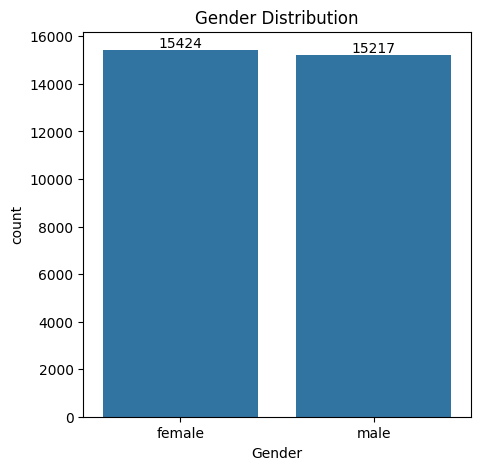

In [ ]:
# Gender distribution

plt.figure(figsize=(5,5))                         # defining size of plot
ax = sns.countplot(x="Gender", data=df_copy)
ax.bar_label(ax.containers[0])                    # show value on top of each bar
plt.title("Gender Distribution")
plt.show()

From the above chart we have analyzed that :

the number of female in the data is more then the males

In [ ]:
# Avg value of MathScore, ReadingScore, WritingScore

gb = df_copy.groupby("ParentEduc").agg({"MathScore":"mean","ReadingScore":"mean","WritingScore":"mean"})
print(gb)

                    MathScore  ReadingScore  WritingScore
ParentEduc                                               
associate's degree  68.365586     71.124324     70.299099
bachelor's degree   70.466627     73.062020     73.331069
high school         64.435731     67.213997     65.421136
master's degree     72.336134     75.832921     76.356896
some college        66.390472     69.179708     68.501432
some high school    62.584013     65.510785     63.632409


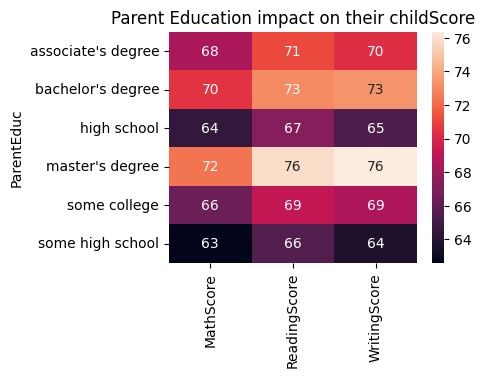

In [ ]:
plt.figure(figsize=(4,3))
sns.heatmap(gb, annot=True)
plt.title("Parent Education impact on their childScore")
plt.show()

From the above chart we have concluded that the education of the Parent have a good impact on their children score

In [ ]:
gb1 = df_copy.groupby("ParentMaritalStatus").agg({"MathScore":"mean","ReadingScore":"mean","WritingScore":"mean"})
print(gb1)

                     MathScore  ReadingScore  WritingScore
ParentMaritalStatus                                       
divorced             66.691197     69.655011     68.799146
married              66.657326     69.389575     68.420981
single               66.165704     69.157250     68.174440
widowed              67.368866     69.651438     68.563452


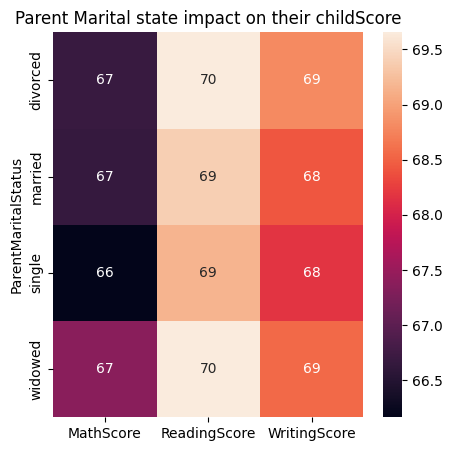

In [ ]:
plt.figure(figsize=(5,5))
sns.heatmap(gb1, annot=True)
plt.title("Parent Marital state impact on their childScore")
plt.show()

From the above chart we have concluded that there is no/negligible impact on student score due to their parent marital state


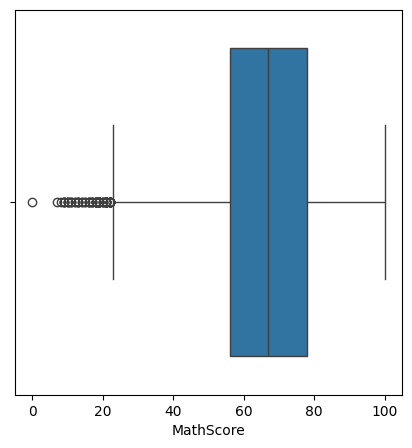

In [ ]:
# checking Outliers
# boxplot tells about outliers

plt.figure(figsize=(5,5))
sns.boxplot(data = df_copy, x = "MathScore")               # one value on zero
plt.show()

From ths graph we assume that students are weak in Math

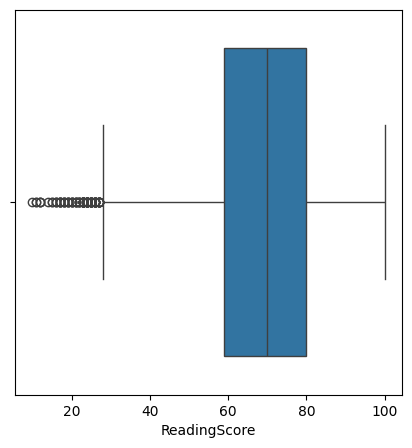

In [ ]:
plt.figure(figsize=(5,5))
sns.boxplot(data = df_copy, x = "ReadingScore")               # no value on zero
plt.show()

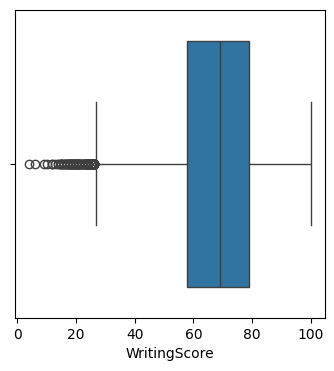

In [ ]:
plt.figure(figsize=(5,5))
sns.boxplot(data = df_copy, x = "WritingScore")               # no value on zero
plt.show()

In [ ]:
df_copy["EthnicGroup"].unique()

array([nan, 'group C', 'group B', 'group A', 'group D', 'group E'],
      dtype=object)

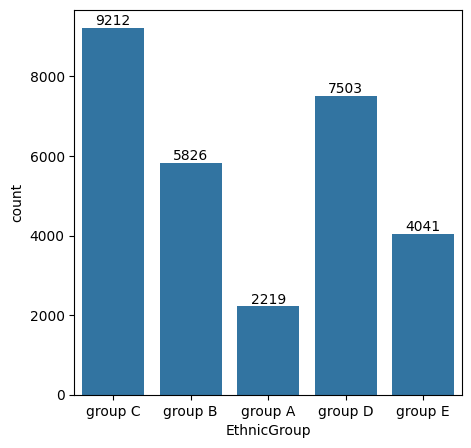

In [ ]:
# Disribution of Ethnic groups

plt.figure(figsize=(5,5))                            # my practice
ax = sns.countplot(x="EthnicGroup", data=df_copy)
ax.bar_label(ax.containers[0])
plt.show()

[np.int64(2219), np.int64(5826), np.int64(9212), np.int64(7503), np.int64(4041)]


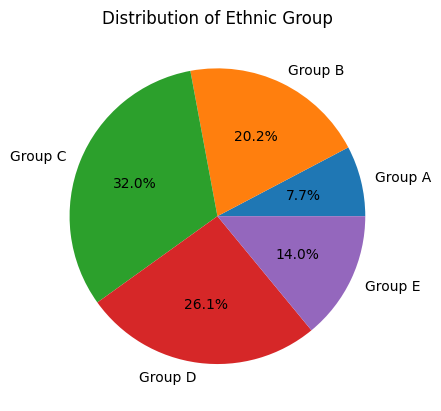

In [ ]:
GroupA = df_copy.loc[(df_copy["EthnicGroup"] == "group A")].count()
GroupB = df_copy.loc[(df_copy["EthnicGroup"] == "group B")].count()
GroupC = df_copy.loc[(df_copy["EthnicGroup"] == "group C")].count()
GroupD = df_copy.loc[(df_copy["EthnicGroup"] == "group D")].count()
GroupE = df_copy.loc[(df_copy["EthnicGroup"] == "group E")].count()


# labels
lbls = ["Group A", "Group B", "Group C", "Group D", "Group E"]

print(mylist)

# only take EthnicGroup Column count
mylist = [GroupA["EthnicGroup"], GroupB["EthnicGroup"], GroupC["EthnicGroup"], GroupD["EthnicGroup"], GroupE["EthnicGroup"]]

plt.pie(mylist, labels=lbls, autopct='%1.1f%%')
plt.title("Distribution of Ethnic Group")
plt.show()
